In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

In [3]:
food_paquet = "C:/Users/Administrateur/Documents/M2i/Tp_Fil_Rouge/repos/Nutriscore/data/food.parquet"

# open_food_facts_df = pd.read_parquet(food_paquet, columns=("countries_tags"))
open_food_facts_df = pd.read_parquet(food_paquet, columns=["countries_tags", "nutriments"])


In [29]:
def filter_by_country(value, country):
    try:
        # Transforme la chaîne JSON en véritable liste Python
        list_array = list(value)
        return country in list_array
    except (json.JSONDecodeError, TypeError):
        # Gestion des erreurs si le JSON est malformé ou s'il y a un NaN
        return False

total_len = len(open_food_facts_df)
france_len = len(open_food_facts_df[open_food_facts_df["countries_tags"].apply(lambda x: filter_by_country(x, "en:france"))])
print(total_len)
print(france_len)

4636471
1247336


In [5]:
def extraire_depuis_liste(liste_nutriments, nom_nutriment):
    if not isinstance(liste_nutriments, (np.ndarray, list)):
        return type(liste_nutriments)
    
    for nutriment in liste_nutriments:
        if isinstance(nutriment, dict) and nutriment.get('name') == nom_nutriment:
            return nutriment.get('100g')

# Application sur le DataFrame Pandas
open_food_facts_df['salt_100g'] = open_food_facts_df['nutriments'].apply(lambda x: extraire_depuis_liste(x, 'salt'))
open_food_facts_df['sugars_100g'] = open_food_facts_df['nutriments'].apply(lambda x: extraire_depuis_liste(x, 'sugars'))
open_food_facts_df['energy_100g'] = open_food_facts_df['nutriments'].apply(lambda x: extraire_depuis_liste(x, 'energy'))


In [14]:
# print(open_food_facts_df['salt_100g'].head(10))

total_no_salt = len(open_food_facts_df[open_food_facts_df['salt_100g'].isna()])
total_no_sugars = len(open_food_facts_df[open_food_facts_df['sugars_100g'].isna()])
total_no_energy = len(open_food_facts_df[open_food_facts_df['energy_100g'].isna()])

ratio_no_salt = total_no_salt / total_len * 100.0
ratio_no_salt_fr = total_no_salt / france_len * 100.0

ratio_no_sugars = total_no_sugars / total_len * 100.0
ratio_no_sugars_fr = total_no_sugars / france_len * 100.0

ratio_no_energy = total_no_energy / total_len * 100.0
ratio_no_energy_fr = total_no_energy / france_len * 100.0

print(f"Sel: {ratio_no_salt} (total)")
print(f"Sel: {ratio_no_salt_fr} (france)")

print(f"Sucres: {ratio_no_sugars} (total)")
print(f"Sucres: {ratio_no_sugars_fr} (france)")

print(f"Énergie: {ratio_no_energy} (total)")
print(f"Énergie: {ratio_no_energy_fr} (france)")


Sel: 14.520634335899004 (total)
Sel: 53.9746307330182 (france)
Sucres: 9.520689334625407 (total)
Sucres: 35.38934176516993 (france)
Énergie: 4.7622210944487735 (total)
Énergie: 17.701645747416894 (france)


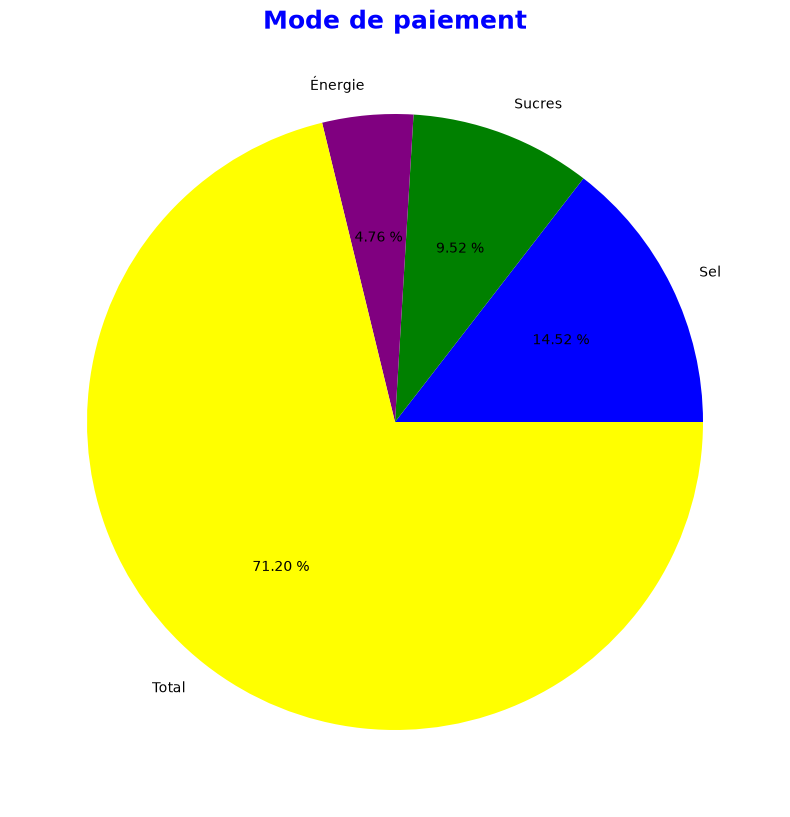

In [16]:
title_dict = {
    "fontsize": 18,
    "fontweight": "bold",
    "color": "blue", 
    "verticalalignment": "baseline"
}

fig, pie_shart = plt.subplots(1, figsize=(16, 10))
pie_shart.set_title("Mode de paiement", fontdict=title_dict)

remains = 100.0 - (ratio_no_salt + ratio_no_sugars + ratio_no_energy)
pie_shart.pie([ratio_no_salt, ratio_no_sugars, ratio_no_energy, remains], labels=["Sel", "Sucres", "Énergie", "Total"], colors=["blue", "green", "purple", "yellow"], autopct="%.2f %%")

In [26]:
"""
Carrefour │ 20732 │
Coop      │ 14545 │
Lidl      │ 14243 │
U         │ 12384 │
Aldi      │ 12353 │
BonÀrea   │ 12155 │
Hacendado │ 10658 │
Auchan    │ 10590 │
Tesco     │ 10503 │
Delhaize  │  9918 |
"""
open_food_facts_df_brands = pd.read_parquet(food_paquet, columns=["brands"])

tmp = open_food_facts_df_brands[open_food_facts_df_brands["brands"] != ''].groupby(["brands"], as_index=False).agg(nb_brands=("brands", "size")).sort_values(by="nb_brands", ascending=False)
tmp = pd.DataFrame(tmp)
print(tmp.head(10))


           brands  nb_brands
71901   Carrefour      20732
89907        Coop      14545
238135       Lidl      14243
399478          U      12384
12877        Aldi      12353
54941     BonÀrea      12155
172437  Hacendado      10658
28022      Auchan      10590
385908      Tesco      10503
105035   Delhaize       9918
